In [1]:
import sys
import os
sys.path.append('../src/')
import create_system_dpd
from create_system_dpd import create_polymer_system_dpd as run
import numpy as np
import numpy as np  
import freud
import gsd, gsd.hoomd 
import hoomd 
import time

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [2]:
time = run(
    num_pol=10,
    num_mon=100,
    density=0.85,
    k=20000,
    bond_l=1.0,
    r_cut=1.15,
    kT=1.0,
    A=1000,
    gamma=800,
    dt=0.001,
    particle_spacing=1.1,
    sim_seed=123,
    np_seed=1234)


1000

Running with A=1000, gamma=800, k=20000, num_pol=10, num_mon=100
Total build time:  0.0008610749991930788
Total build and simulation time: 3.801455939999869


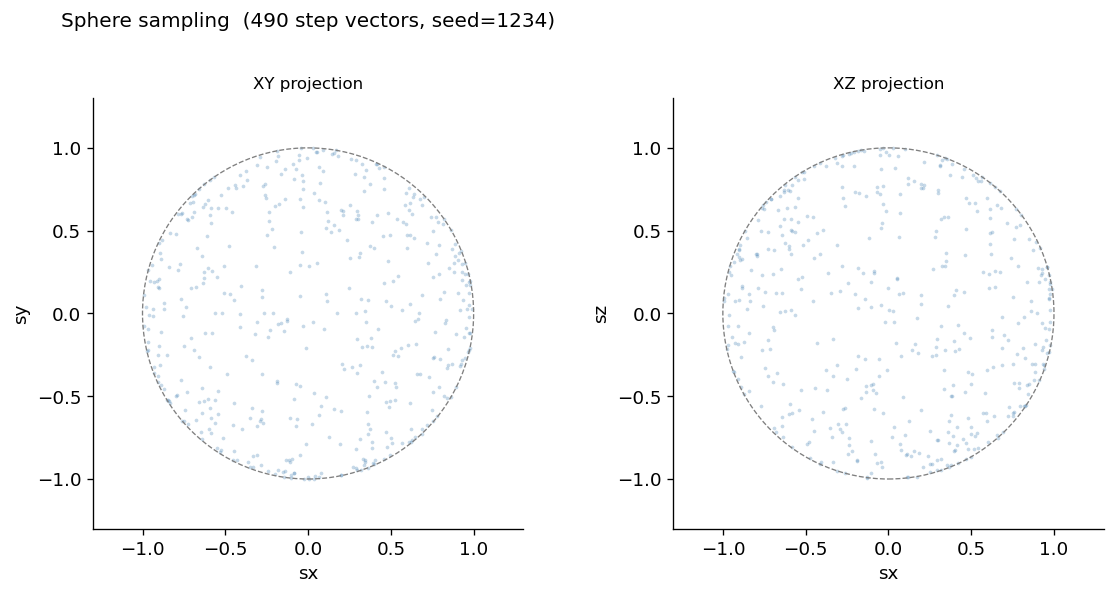

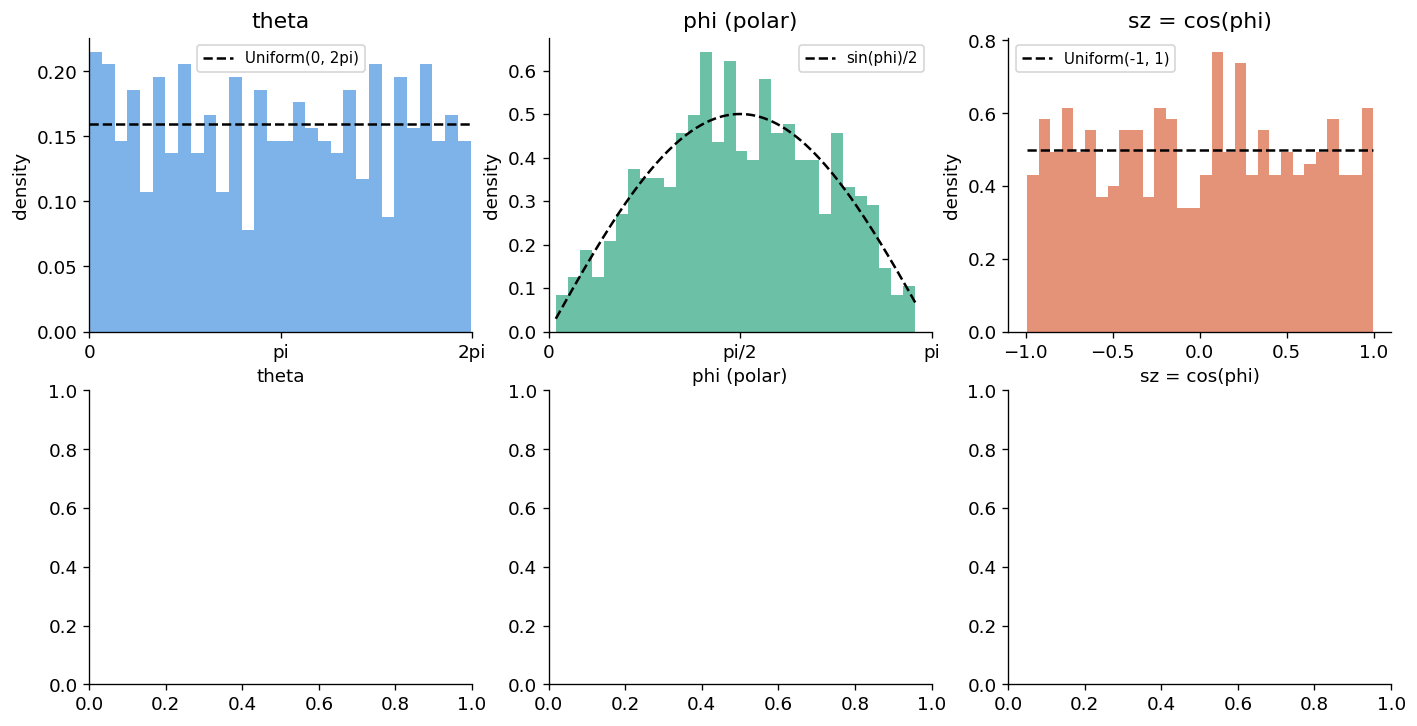

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

NUM_POL  = 10      # number of polymer chains
NUM_MON  = 50      # monomers per chain
DENSITY  = 0.85
BOND_LEN = 1.0
SEED     = 1234

N_STEPS = NUM_POL * (NUM_MON - 1)   # total step vectors sampled

rng = np.random.default_rng(SEED)

thetas = rng.uniform(0, 2 * np.pi, size=(NUM_POL, NUM_MON - 1))     # azimuth
phis   = np.arccos(rng.uniform(-1, 1, size=(NUM_POL, NUM_MON - 1))) # polar (uniform on sphere)

# unit step vectors
sx = np.sin(phis) * np.cos(thetas)
sy = np.sin(phis) * np.sin(thetas)
sz = np.cos(phis)

# flatten for distribution plots
thetas_flat = thetas.ravel()
phis_flat   = phis.ravel()
sx_flat, sy_flat, sz_flat = sx.ravel(), sy.ravel(), sz.ravel()

fig = plt.figure(figsize=(14, 5))

# --- XY 2-D projection ---
ax_xy = fig.add_subplot(111)
ax_xy.scatter(sx_flat, sy_flat, s=5, alpha=0.3, color='steelblue', linewidths=0)
circle = plt.Circle((0, 0), 1, fill=False, color='grey', linewidth=0.8, linestyle='--')
ax_xy.add_patch(circle)
ax_xy.set_aspect('equal')
ax_xy.set_title('XY projection', fontsize=10)
ax_xy.set_xlabel('sx'); ax_xy.set_ylabel('sy')
ax_xy.set_xlim(-1.3, 1.3); ax_xy.set_ylim(-1.3, 1.3)

# --- XZ 2-D projection ---
ax_xz = fig.add_subplot(133)
ax_xz.scatter(sx_flat, sz_flat, s=5, alpha=0.3, color='steelblue', linewidths=0)
circle = plt.Circle((0, 0), 1, fill=False, color='grey', linewidth=0.8, linestyle='--')
ax_xz.add_patch(circle)
ax_xz.set_aspect('equal')
ax_xz.set_title('XZ projection', fontsize=10)
ax_xz.set_xlabel('sx'); ax_xz.set_ylabel('sz')
ax_xz.set_xlim(-1.3, 1.3); ax_xz.set_ylim(-1.3, 1.3)

fig.suptitle(f'Sphere sampling  ({N_STEPS} step vectors, seed={SEED})', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

BINS = max(30, N_STEPS // 30)

def plot_hist(ax, data, label, color, ref_fn=None, ref_label=None, xlim=None):
    ax.hist(data, bins=BINS, density=True, color=color, alpha=0.65, edgecolor='none')
    if ref_fn is not None:
        xs = np.linspace(data.min(), data.max(), 300)
        ax.plot(xs, ref_fn(xs), 'k--', linewidth=1.5, label=ref_label)
        ax.legend(fontsize=9)
    ax.set_xlabel(label); ax.set_ylabel('density')
    if xlim:
        ax.set_xlim(xlim)
    ax.set_title(label)

def arcsine_pdf(x):
    x = np.clip(x, -1 + 1e-6, 1 - 1e-6)
    return 1 / (np.pi * np.sqrt(1 - x**2))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

plot_hist(axes[0, 0], thetas_flat, 'theta', '#378ADD',
          ref_fn=lambda x: np.full_like(x, 1 / (2 * np.pi)),
          ref_label='Uniform(0, 2pi)', xlim=(0, 2 * np.pi))
axes[0, 0].set_xticks([0, np.pi, 2 * np.pi])
axes[0, 0].set_xticklabels(['0', 'pi', '2pi'])

plot_hist(axes[0, 1], phis_flat, 'phi (polar)', '#1D9E75',
          ref_fn=lambda x: np.sin(x) / 2,
          ref_label='sin(phi)/2', xlim=(0, np.pi))
axes[0, 1].set_xticks([0, np.pi / 2, np.pi])
axes[0, 1].set_xticklabels(['0', 'pi/2', 'pi'])

plot_hist(axes[0, 2], sz_flat, 'sz = cos(phi)', '#D85A30',
          ref_fn=lambda x: np.full_like(x, 0.5),
          ref_label='Uniform(-1, 1)', xlim=(-1.1, 1.1))